<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework4Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/Cancer.csv'
data = pd.DataFrame(pd.read_csv(filetest))
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
data = data.drop(columns=['Unnamed: 32'])

data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

X = data.drop(columns=['diagnosis'])
Y = data['diagnosis']

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=50)

In [ ]:
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [ ]:
kernels = ['linear', 'poly', 'rbf']

aresults = []
presults = []
rresults = []

In [ ]:
for kernel in kernels:

  model = SVC(kernel=kernel)
  model.fit(Xtrain, Ytrain)

  Ypres = model.predict(Xtest)

  accuracy = accuracy_score(Ytest, Ypres)
  precision = precision_score(Ytest, Ypres)
  recall = recall_score(Ytest, Ypres)

  aresults.append(accuracy)
  presults.append(precision)
  rresults.append(recall)

  print(f'Kernel: {kernel}')
  print(f'Accuracy: {accuracy}')
  print(f'Precision: {precision}')
  print(f'Recall: {recall}')

Kernel: linear
Accuracy: 0.9912280701754386
Precision: 1.0
Recall: 0.9743589743589743
Kernel: poly
Accuracy: 0.9035087719298246
Precision: 1.0
Recall: 0.717948717948718
Kernel: rbf
Accuracy: 0.9649122807017544
Precision: 0.9069767441860465
Recall: 1.0


In [ ]:
results = pd.DataFrame({'Kernel': kernels, 'Accuracy': aresults, 'Precision': presults, 'Recall': rresults})
results

print(results)

   Kernel  Accuracy  Precision    Recall
0  linear  0.991228   1.000000  0.974359
1    poly  0.903509   1.000000  0.717949
2     rbf  0.964912   0.906977  1.000000


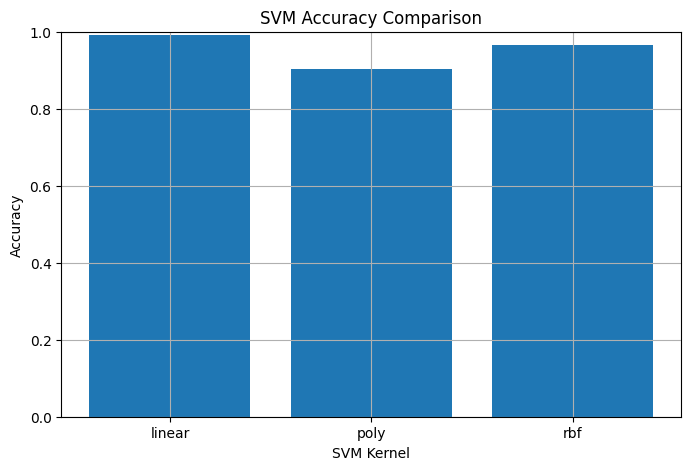

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(kernels, aresults)

plt.xlabel('SVM Kernel')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy Comparison')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

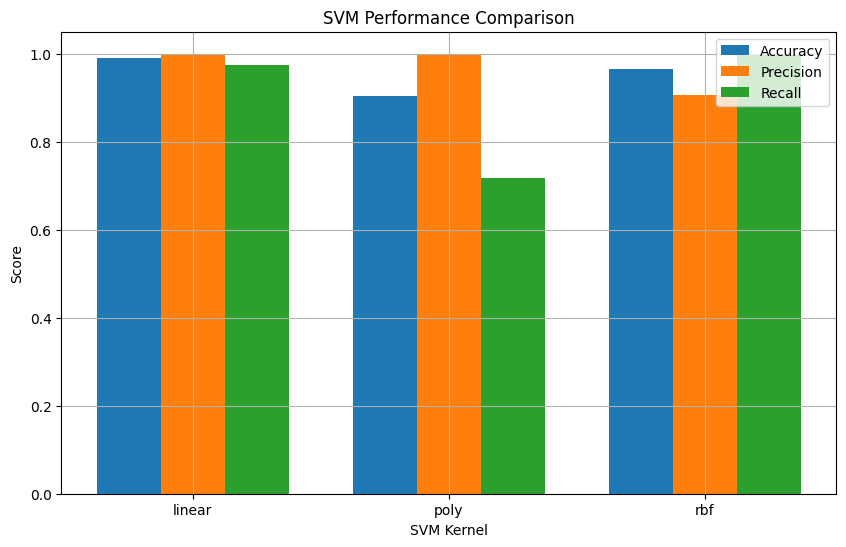

In [ ]:
x = np.arange(len(kernels))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, aresults, width, label='Accuracy')
plt.bar(x, presults, width, label='Precision')
plt.bar(x + width, rresults, width, label='Recall')

plt.xlabel('SVM Kernel')
plt.ylabel('Score')
plt.title('SVM Performance Comparison')
plt.grid(True)
plt.xticks(x, kernels)
plt.ylim(0, 1.05)

plt.legend()
plt.show()